# Spotify Streaming History: An Exploratory Data Analysis

In [11]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# List of all your streaming history JSON files
file_names = [
    # 'Streaming_History_Audio_2020-2023_0.json',
    # 'Streaming_History_Audio_2023-2024_1.json',
    'Streaming_History_Audio_2024-2025_2.json',
    'Streaming_History_Audio_2025_3.json'
]

list_of_dfs = []
files_loaded = 0

for file in file_names:
    try:
        with open(file, 'r', encoding='utf-8') as f:
            data = json.load(f)
            list_of_dfs.append(pd.DataFrame(data))
            print(f"Successfully loaded: {file}")
            files_loaded += 1
    except FileNotFoundError:
        print(f"Warning: File not found - {file}. Skipping.")
    except json.JSONDecodeError:
        print(f"Warning: Could not decode JSON from {file}. The file might be empty or corrupt. Skipping.")

# Combine all loaded data into a single DataFrame
if list_of_dfs:
    df = pd.concat(list_of_dfs, ignore_index=True)
    print(f"\nSuccessfully loaded and combined {files_loaded} file(s).")
    print("Total DataFrame shape:", df.shape)
else:
    print("\nNo data was loaded. Please check your file names and ensure they are uploaded.")
    df = pd.DataFrame() # Create an empty dataframe to avoid further errors

Successfully loaded: Streaming_History_Audio_2024-2025_2.json
Successfully loaded: Streaming_History_Audio_2025_3.json

Successfully loaded and combined 2 file(s).
Total DataFrame shape: (20072, 23)


In [12]:
if not df.empty:
    # Convert 'ts' column to datetime objects
    df['ts'] = pd.to_datetime(df['ts'])

    # Extract useful time-based features
    df['year'] = df['ts'].dt.year
    df['month'] = df['ts'].dt.month
    df['day_of_week'] = df['ts'].dt.day_name()
    df['hour'] = df['ts'].dt.hour

    # Calculate listening duration in minutes
    df['duration_min'] = df['ms_played'] / 60000

    print("Data preprocessing complete.")

Data preprocessing complete.


In [13]:
if not df.empty:
    # Top 10 Artists
    top_artists = df['master_metadata_album_artist_name'].value_counts().head(10)
    print("\nTop 10 Artists (All Time):\n", top_artists)

    # Top 10 Tracks
    top_tracks = df['master_metadata_track_name'].value_counts().head(10)
    print("\nTop 10 Tracks (All Time):\n", top_tracks)


Top 10 Artists (All Time):
 master_metadata_album_artist_name
Seedhe Maut     1509
Talha Anjum      896
Farhan Khan      706
The Siege        670
trick/switch     436
Rawal            431
DRV              422
Shyko Music      408
A. Roy           373
Frappe Ash       356
Name: count, dtype: int64

Top 10 Tracks (All Time):
 master_metadata_track_name
Since Tum                                        74
Jawab De                                         71
Aankhon Ne Maara                                 61
Kalopsia (Duster)                                56
I Don't Have Distortion and I Don't Have Hope    54
Dhak Dhak                                        54
Masoom                                           53
Ajnabi                                           53
Butterfly Paralysed                              52
Khoobsurat Gaanv                                 51
Name: count, dtype: int64


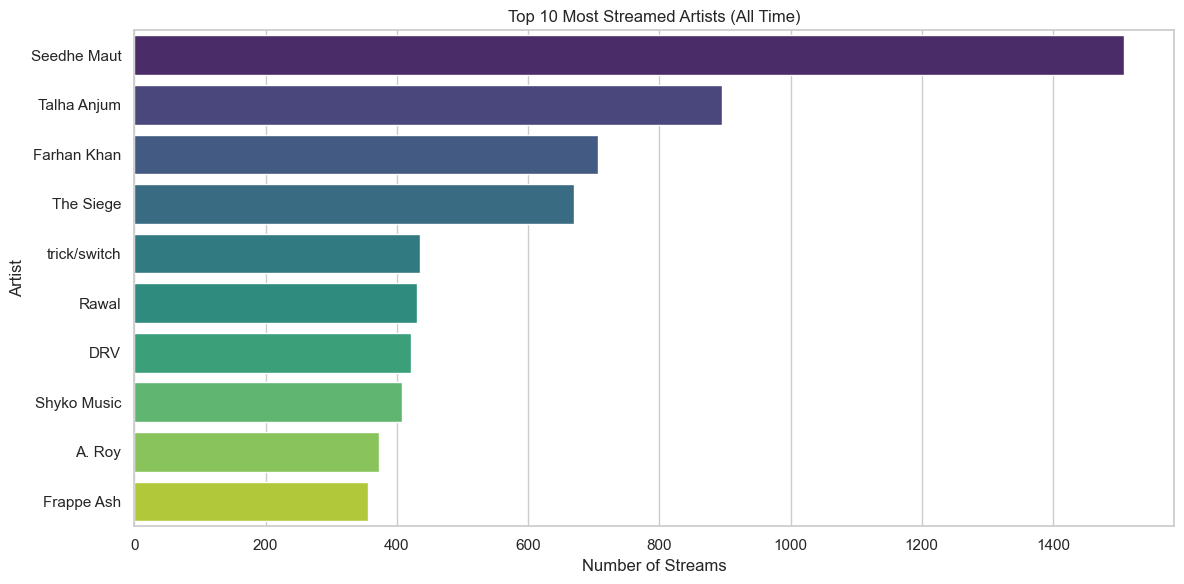

In [14]:
# Set the style for all subsequent plots
sns.set(style="whitegrid")

# Create the bar chart for top artists
if not df.empty:
    plt.figure(figsize=(12, 6))
    # FIXED: Added hue=top_artists.index and legend=False
    sns.barplot(x=top_artists.values, y=top_artists.index, hue=top_artists.index, palette="viridis", legend=False)
    plt.title('Top 10 Most Streamed Artists (All Time)')
    plt.xlabel('Number of Streams')
    plt.ylabel('Artist')
    plt.tight_layout()
    plt.show()

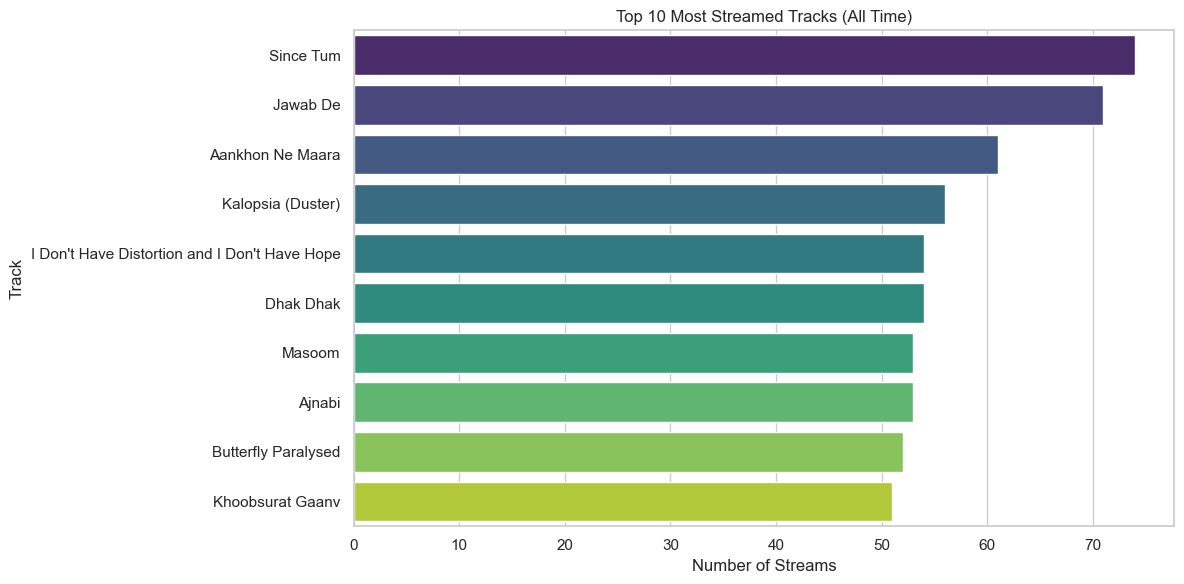

In [15]:
# Create the bar chart for top tracks
if not df.empty:
    plt.figure(figsize=(12, 6))
    # FIXED: Changed palette to "viridis", added hue and legend=False
    sns.barplot(x=top_tracks.values, y=top_tracks.index, hue=top_tracks.index, palette="viridis", legend=False)
    plt.title('Top 10 Most Streamed Tracks (All Time)')
    plt.xlabel('Number of Streams')
    plt.ylabel('Track')
    plt.tight_layout()
    plt.show()

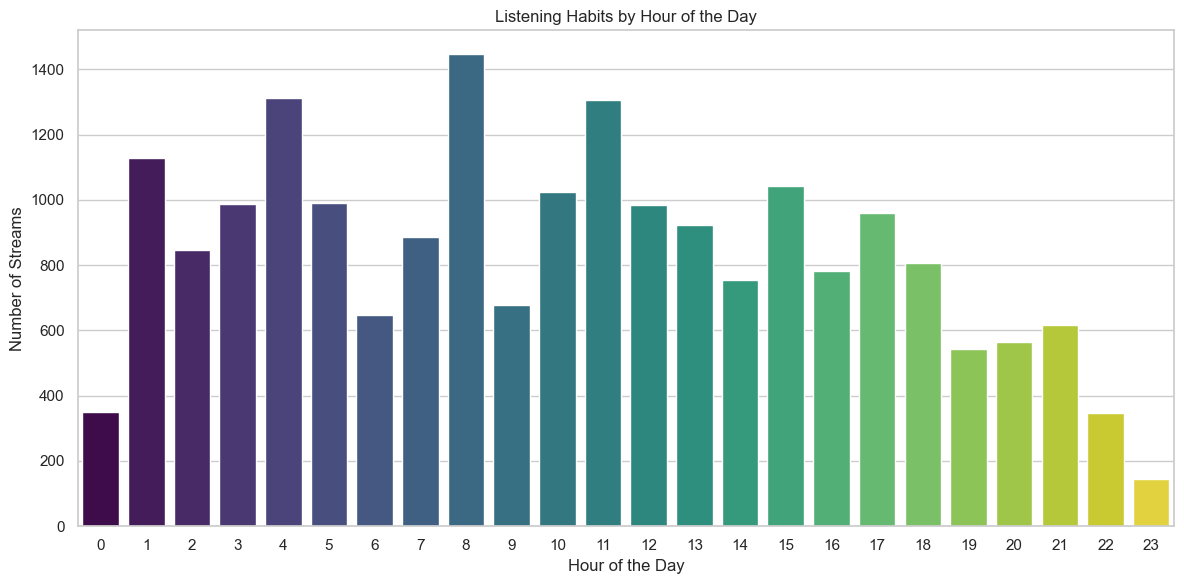

In [16]:
# Create the count plot for listening by hour
if not df.empty:
    plt.figure(figsize=(12, 6))
    # FIXED: Changed palette to "viridis", added hue and legend=False
    sns.countplot(x='hour', data=df, hue='hour', palette="viridis", legend=False)
    plt.title('Listening Habits by Hour of the Day')
    plt.xlabel('Hour of the Day')
    plt.ylabel('Number of Streams')
    plt.tight_layout()
    plt.show()

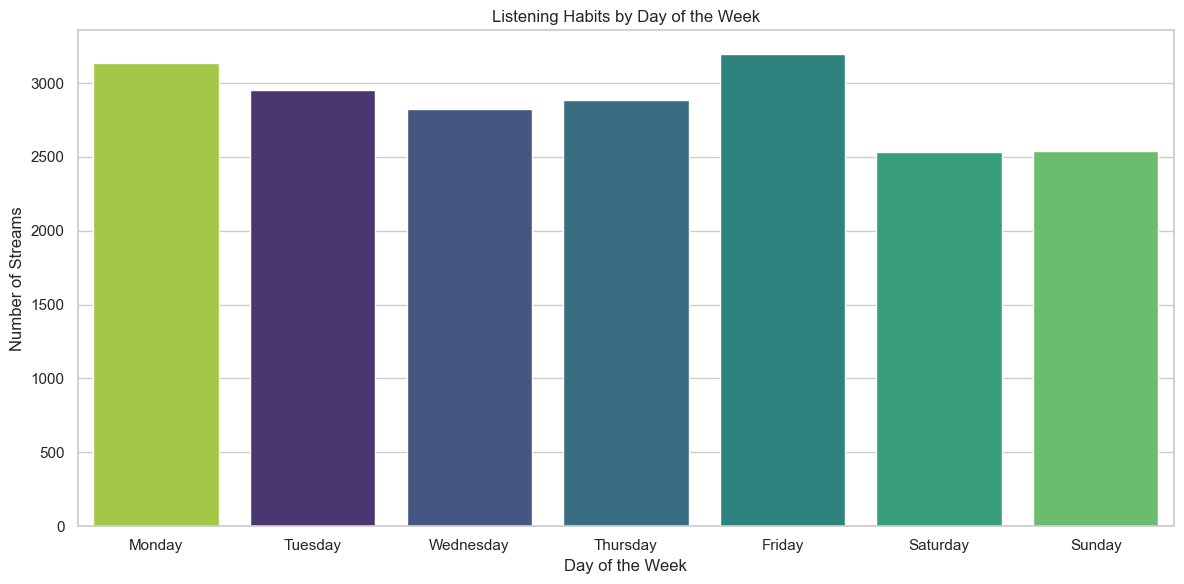

In [17]:
# Create the count plot for listening by day
if not df.empty:
    plt.figure(figsize=(12, 6))
    day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    # FIXED: Changed palette to "viridis", added hue and legend=False
    sns.countplot(x='day_of_week', data=df, order=day_order, hue='day_of_week', palette="viridis", legend=False)
    plt.title('Listening Habits by Day of the Week')
    plt.xlabel('Day of the Week')
    plt.ylabel('Number of Streams')
    plt.tight_layout()
    plt.show()

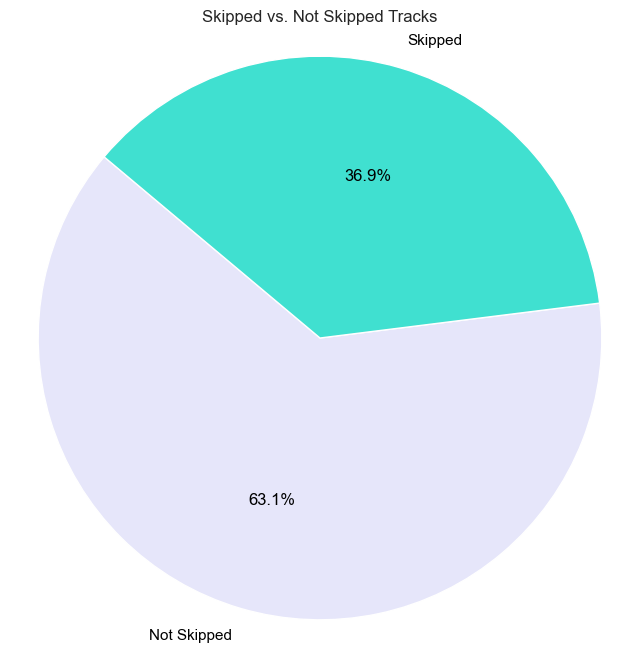

In [18]:
if not df.empty:
    skipped_counts = df['skipped'].value_counts()
    plt.figure(figsize=(8, 8))
    plt.pie(
        skipped_counts,
        labels=['Not Skipped', 'Skipped'],
        autopct='%1.1f%%',
        startangle=140,
        colors=['lavender', 'Turquoise'],
        textprops={'color': 'black'}  # 👈 makes labels and percentages black
    )
    plt.title('Skipped vs. Not Skipped Tracks')
    plt.axis('equal') # Ensures the pie chart is a circle

    plt.show()


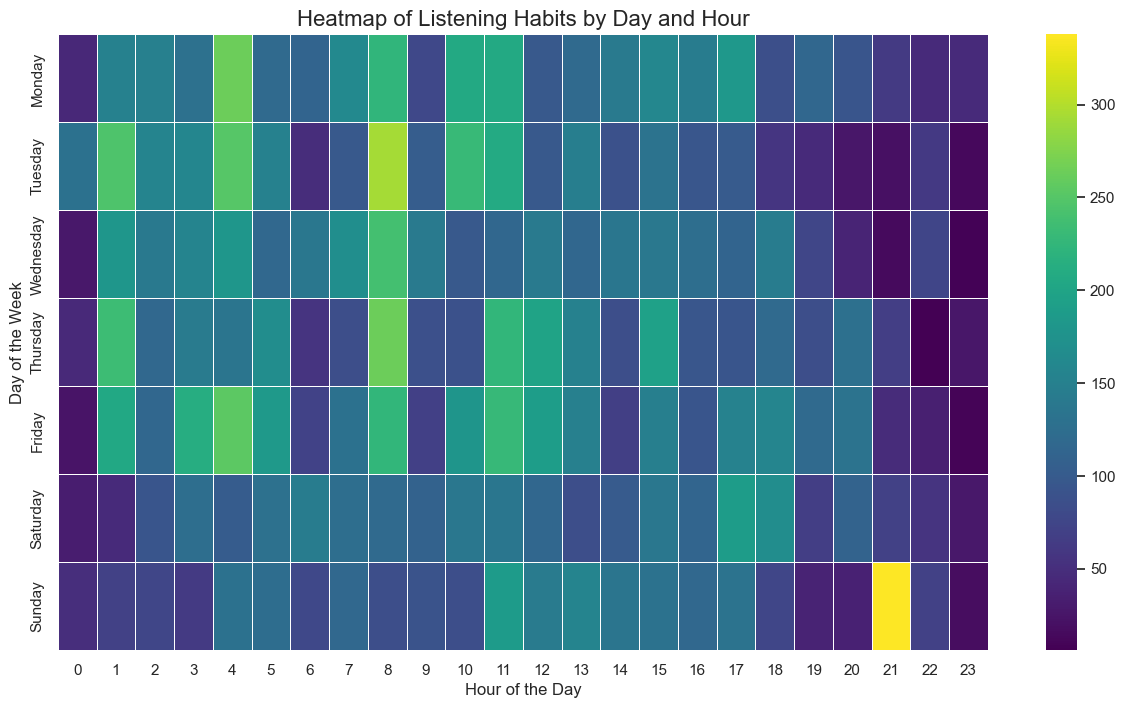

In [19]:
if not df.empty:
    # Group data by day and hour to create the heatmap matrix
    heatmap_data = df.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)

    # Reorder the days of the week for a logical layout
    day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    heatmap_data = heatmap_data.reindex(day_order)

    # Create the heatmap plot
    plt.figure(figsize=(15, 8))
    # FIXED: Changed cmap to "viridis"
    sns.heatmap(heatmap_data, cmap="viridis", linewidths=.5)
    plt.title('Heatmap of Listening Habits by Day and Hour', fontsize=16)
    plt.xlabel('Hour of the Day')
    plt.ylabel('Day of the Week')
    plt.show()

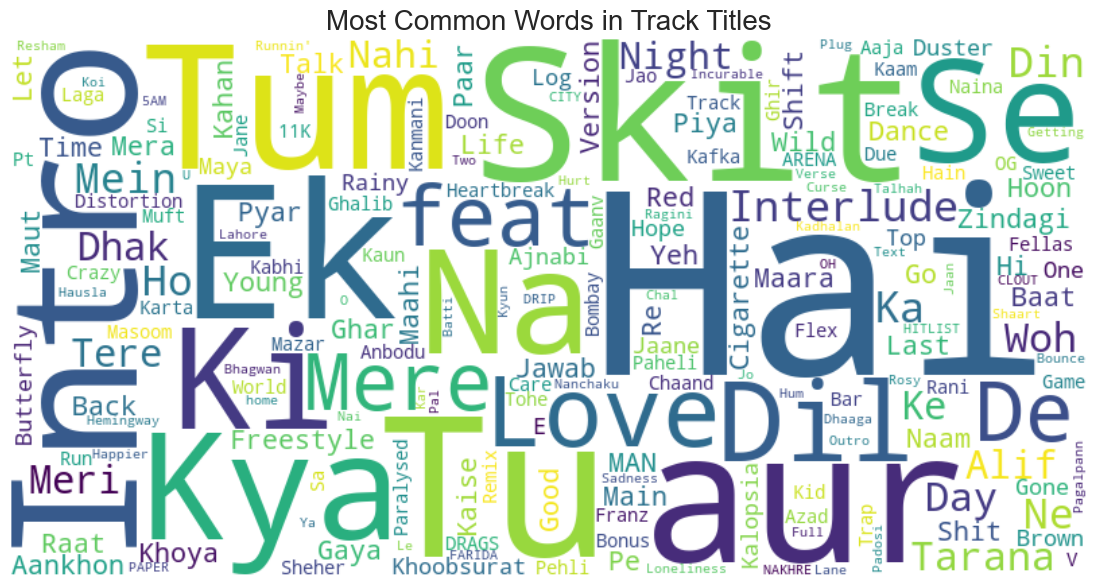

In [20]:
from wordcloud import WordCloud

if not df.empty:
    # Combine all track names into one long string, dropping any missing names
    text = " ".join(track for track in df['master_metadata_track_name'].dropna())

    # Configure and generate the word cloud
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='viridis',
        collocations=False
    ).generate(text)

    # Display the word cloud
    plt.figure(figsize=(15, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title('Most Common Words in Track Titles', fontsize=20)
    plt.show()

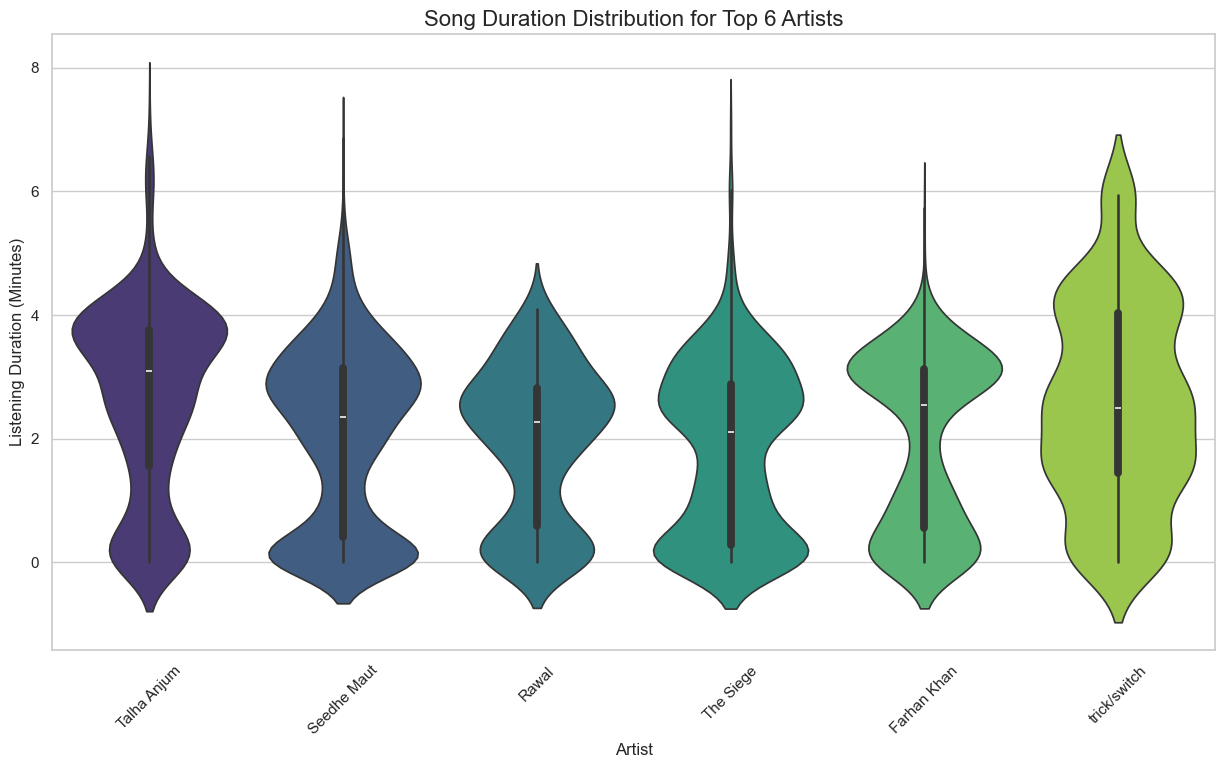

In [21]:
if not df.empty:
    # Get the list of your top 6 artists
    top_6_artists = df['master_metadata_album_artist_name'].value_counts().head(6).index

    # Filter the DataFrame to only include data for these top 6 artists
    df_top_artists = df[df['master_metadata_album_artist_name'].isin(top_6_artists)]

    # Create the violin plot
    plt.figure(figsize=(15, 8))
    # FIXED: Added hue and legend=False to resolve the FutureWarning
    sns.violinplot(
        x='master_metadata_album_artist_name',
        y='duration_min',
        data=df_top_artists,
        palette='viridis',
        hue='master_metadata_album_artist_name',
        legend=False
    )
    plt.title('Song Duration Distribution for Top 6 Artists', fontsize=16)
    plt.xlabel('Artist')
    plt.ylabel('Listening Duration (Minutes)')
    plt.xticks(rotation=45)
    plt.show()

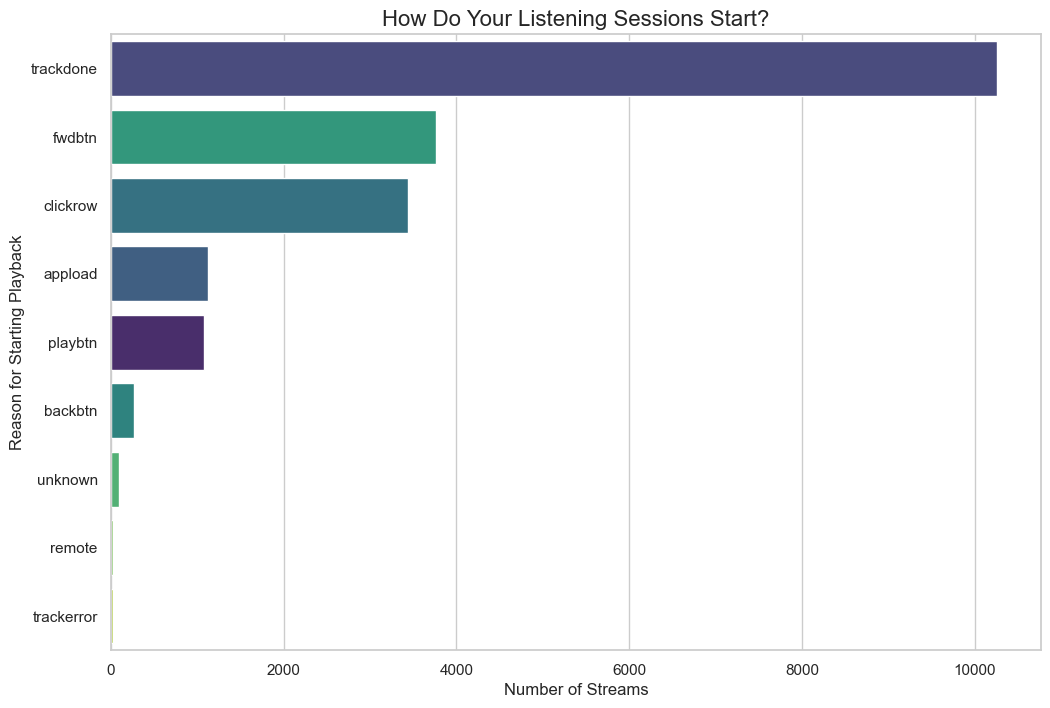

In [22]:
if not df.empty:
    plt.figure(figsize=(12, 8))
    # FIXED: Added hue and legend=False
    sns.countplot(y='reason_start', data=df, order = df['reason_start'].value_counts().index, hue='reason_start', palette='viridis', legend=False)
    plt.title('How Do Your Listening Sessions Start?', fontsize=16)
    plt.xlabel('Number of Streams')
    plt.ylabel('Reason for Starting Playback')
    plt.show()

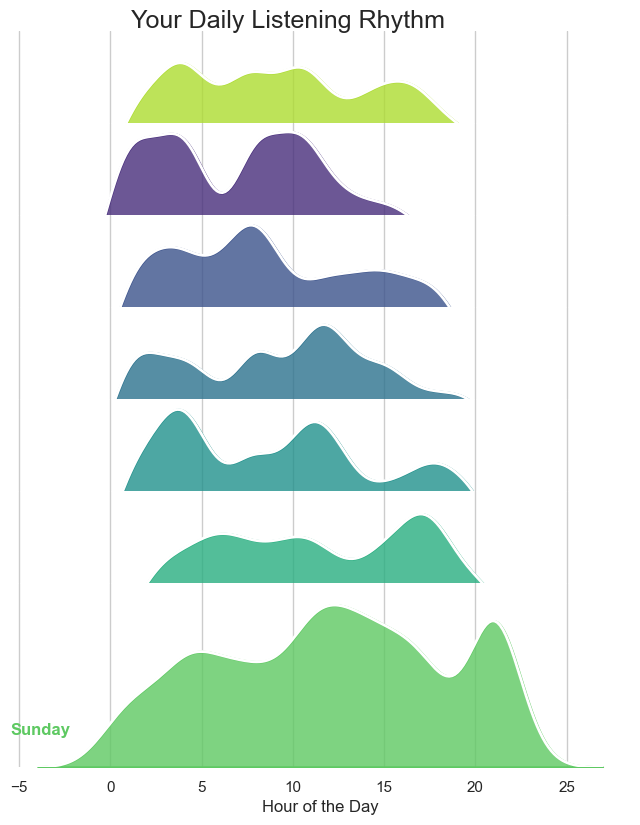

In [23]:
if not df.empty:
    # Set up the plot using seaborn's FacetGrid
    g = sns.FacetGrid(df, row="day_of_week", hue="day_of_week", aspect=6, height=1.2, palette='viridis',
                      row_order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])

    # Draw the kernel density plots for each day
    g.map(sns.kdeplot, "hour", fill=True, alpha=0.8, lw=2)

    # Add a white line for each plot to make them distinct
    g.map(sns.kdeplot, "hour", color="w", lw=2)

    # Function to add the day's name to each plot
    def label(x, color, label):
        ax = plt.gca()
        ax.text(0, .2, label, fontweight="bold", color=color,
                ha="left", va="center", transform=ax.transAxes)

    g.map(label, "hour")

    # Clean up the plot
    g.fig.subplots_adjust(hspace=-0.5)
    g.set_titles("")
    g.set(yticks=[], ylabel="")
    g.despine(bottom=True, left=True)

    plt.suptitle('Your Daily Listening Rhythm', y=0.98, fontsize=18)
    plt.xlabel('Hour of the Day')
    plt.show()

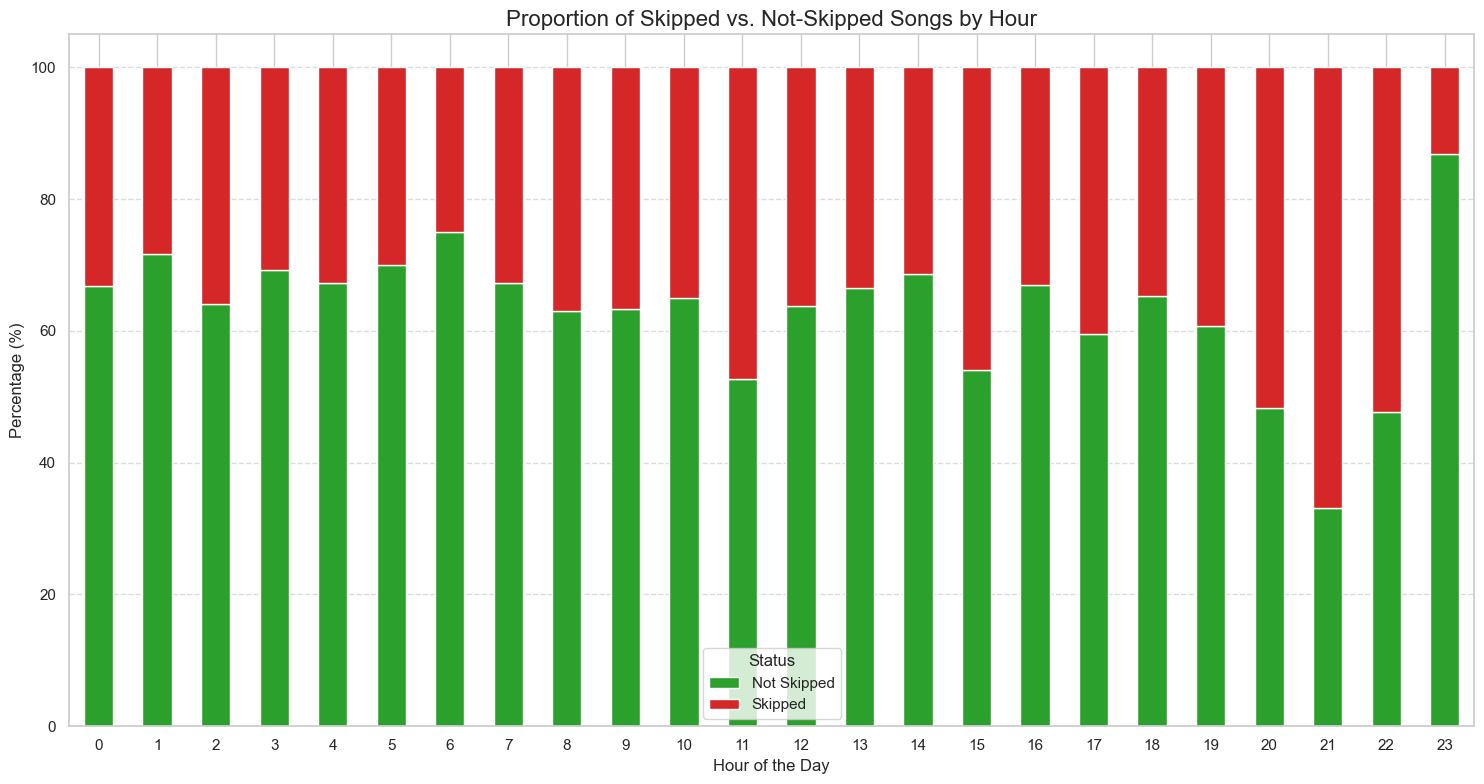

In [24]:
timestamp_column_name = 'ts'

if not df.empty and timestamp_column_name in df.columns:
    # 1. Ensure the timestamp column is in the correct datetime format
    df[timestamp_column_name] = pd.to_datetime(df[timestamp_column_name])

    # 2. Create the 'hour' column by extracting the hour from the timestamp
    df['hour'] = df[timestamp_column_name].dt.hour
    # --- End of Fix ---


    # 3. Group by hour and skipped status, then count the occurrences
    # This part is from your original code
    skip_data = df.groupby(['hour', 'skipped']).size().unstack(fill_value=0)

    # 4. Calculate the percentage for a proportional view
    skip_data_percent = skip_data.apply(lambda x: x * 100 / sum(x), axis=1)

    # 5. Create the stacked bar chart
    skip_data_percent.plot(
        kind='bar',
        stacked=True,
        color=['#2ca02c', '#d62728'],  # Green for not skipped, Red for skipped
        figsize=(15, 8)
    )

    # --- Chart Customization ---
    plt.title('Proportion of Skipped vs. Not-Skipped Songs by Hour', fontsize=16)
    plt.xlabel('Hour of the Day')
    plt.ylabel('Percentage (%)')
    plt.legend(title='Status', labels=['Not Skipped', 'Skipped'])
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

else:
    if df.empty:
        print("DataFrame is empty. Cannot process.")
    else:
        print(f"Error: The timestamp column '{timestamp_column_name}' was not found in the DataFrame.")
        print(f"Available columns are: {df.columns.tolist()}")

Generating Calendar Heatmap...


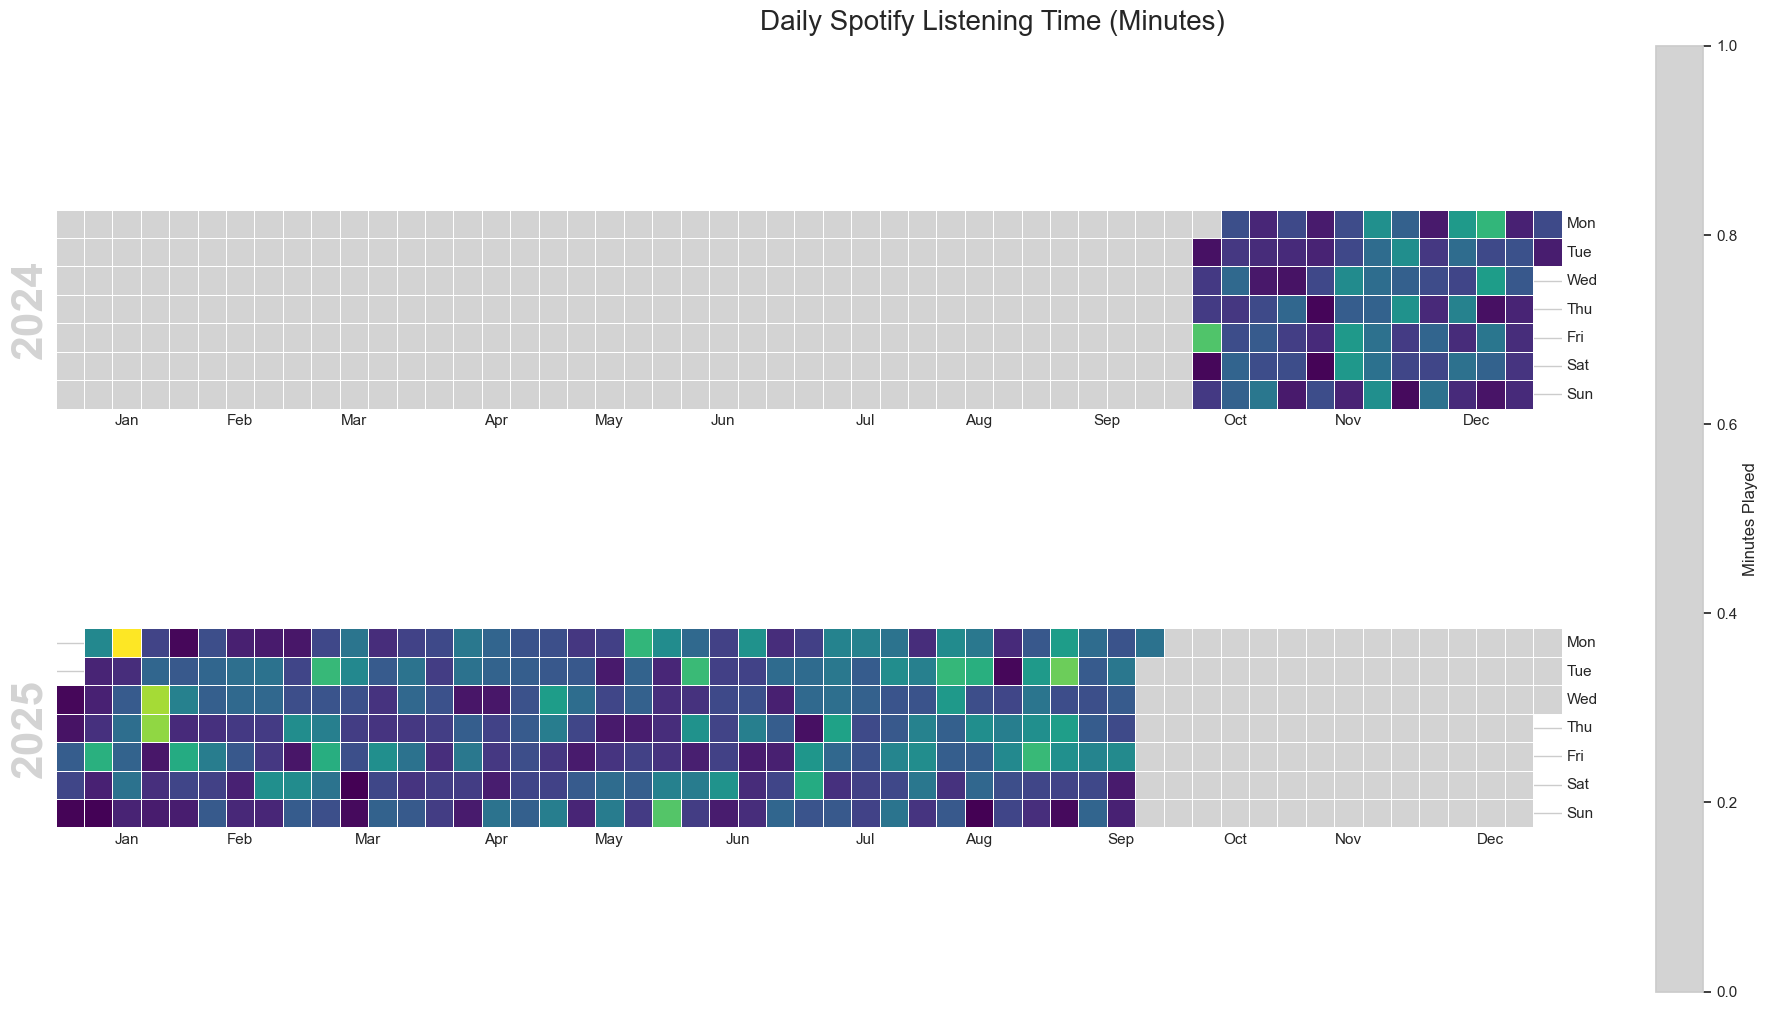

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import calmap


print("Generating Calendar Heatmap...")
daily_minutes = df.groupby(df['ts'].dt.date)['duration_min'].sum()
daily_minutes.index = pd.to_datetime(daily_minutes.index)


# Let calmap create the figure and axes, then capture them
fig, axes = calmap.calendarplot(
    daily_minutes,
    cmap='viridis',
    fillcolor='lightgrey',
    linewidth=0.5,
    fig_kws={'figsize': (20, 10)} # Pass figure settings here
)
# Add a color bar and a title for the entire figure
fig.colorbar(axes[0].get_children()[0], ax=axes.ravel().tolist(), orientation='vertical', label='Minutes Played', pad=0.05)
fig.suptitle("Daily Spotify Listening Time (Minutes)", fontsize=20, y=1.0)
plt.show()



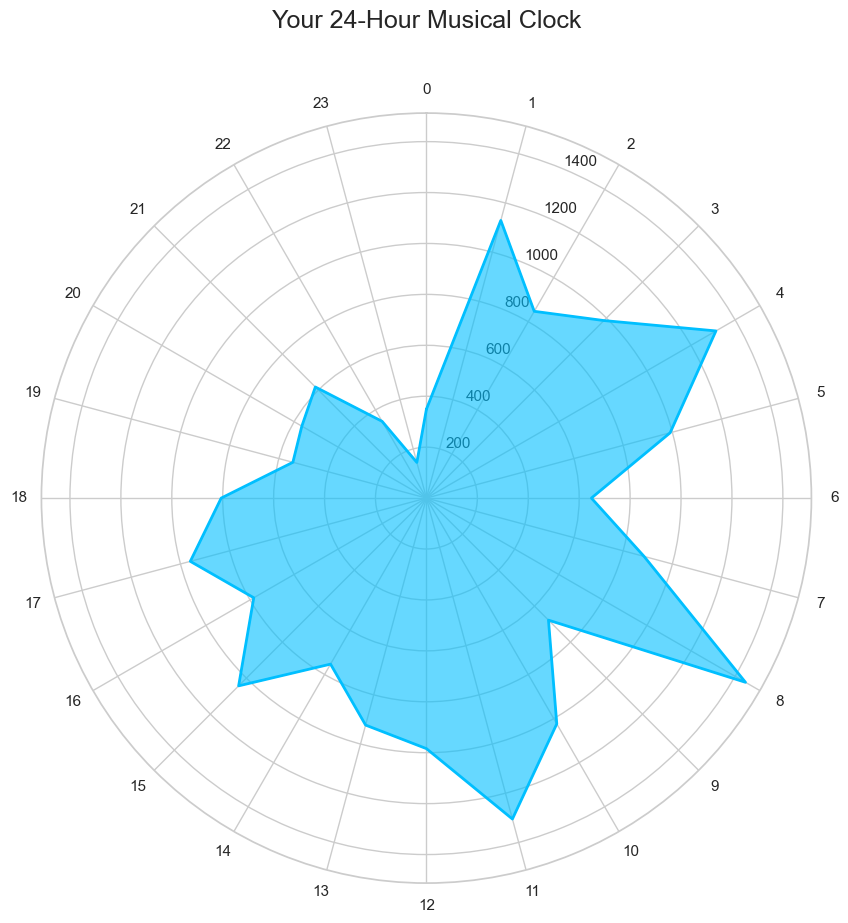

In [26]:
import numpy as np

if not df.empty:
    # Group data by hour and count the number of streams
    hourly_counts = df.groupby('hour').size()

    # Prepare the data for a circular plot
    angles = np.linspace(0, 2 * np.pi, 24, endpoint=False)
    angles = np.concatenate((angles, [angles[0]]))
    hourly_counts = pd.concat([hourly_counts, hourly_counts.head(1)])

    # Create the polar plot
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    ax.fill(angles, hourly_counts, color='deepskyblue', alpha=0.6)
    ax.plot(angles, hourly_counts, color='deepskyblue', linewidth=2)

    # Set the direction of the clock
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    # Set the hour labels
    ax.set_xticks(np.linspace(0, 2 * np.pi, 24, endpoint=False))
    ax.set_xticklabels(range(24))
    ax.set_title('Your 24-Hour Musical Clock', fontsize=18, y=1.1)

    plt.show()

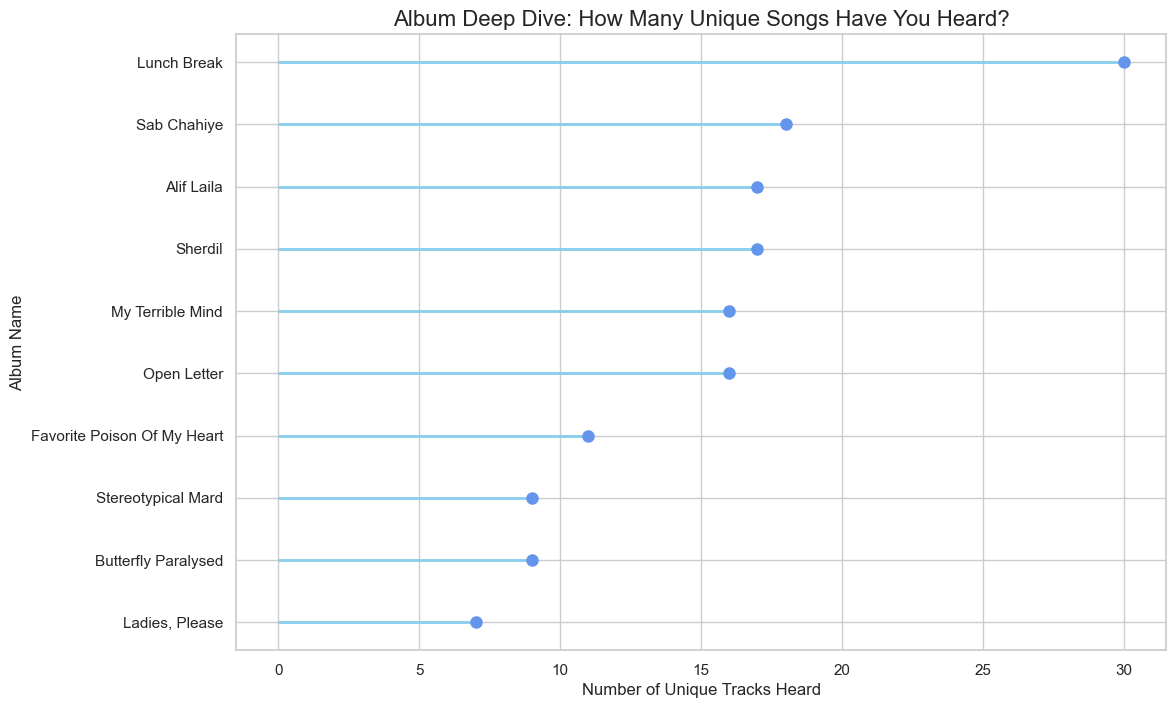

In [27]:
if not df.empty:
    # Find your top 10 most streamed albums
    top_10_albums = df['master_metadata_album_album_name'].value_counts().head(10).index

    # Filter the dataframe to only include these albums
    df_top_albums = df[df['master_metadata_album_album_name'].isin(top_10_albums)]

    # For each album, count how many unique songs you've played
    unique_songs_per_album = df_top_albums.groupby('master_metadata_album_album_name')['master_metadata_track_name'].nunique().sort_values()

    # Create the lollipop plot
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.hlines(
        y=unique_songs_per_album.index,
        xmin=0,
        xmax=unique_songs_per_album.values,
        color='skyblue',
        linewidth=2
    )
    ax.plot(unique_songs_per_album.values, unique_songs_per_album.index, "o", markersize=8, color='cornflowerblue')

    ax.set_title('Album Deep Dive: How Many Unique Songs Have You Heard?', fontsize=16)
    ax.set_xlabel('Number of Unique Tracks Heard')
    ax.set_ylabel('Album Name')
    plt.show()

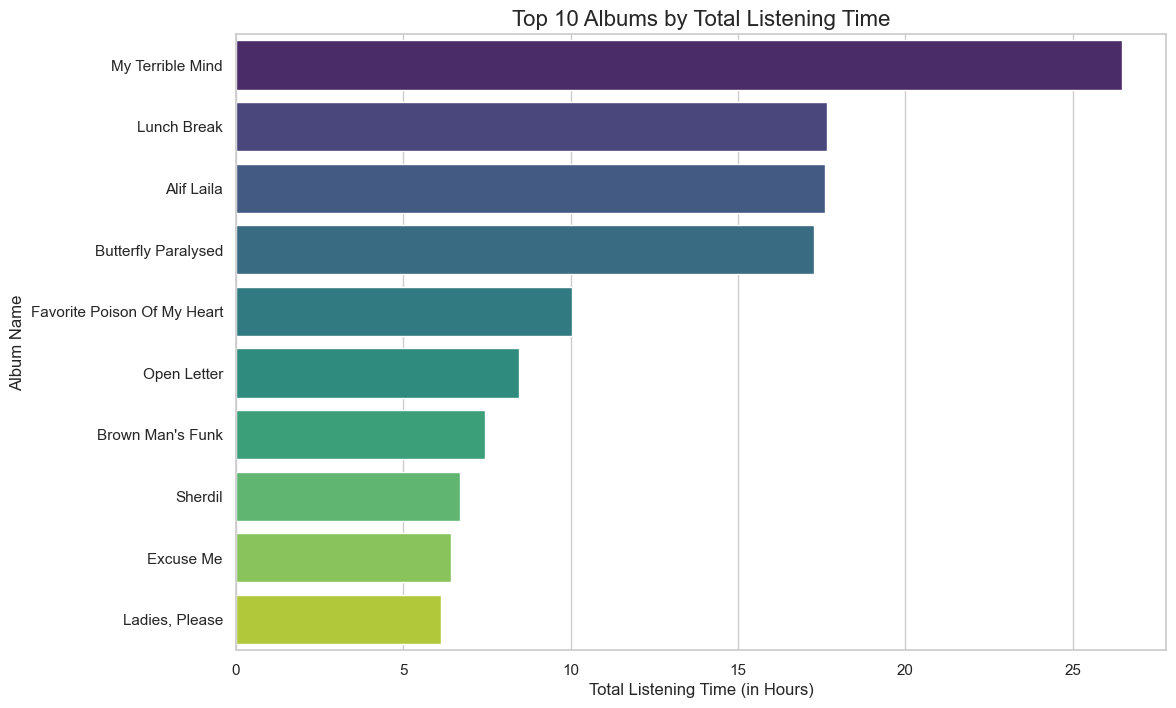

In [28]:
if not df.empty:
    # Group by album name and sum the total milliseconds played
    album_listening_time = df.groupby('master_metadata_album_album_name')['ms_played'].sum()

    # Convert milliseconds to hours and get the top 10
    album_listening_time_hours = (album_listening_time / (1000 * 60 * 60)).sort_values(ascending=False).head(10)

    # Create a horizontal bar chart
    plt.figure(figsize=(12, 8))
    # FIXED: Changed palette to "viridis", added hue and legend=False
    sns.barplot(x=album_listening_time_hours.values, y=album_listening_time_hours.index, hue=album_listening_time_hours.index, palette='viridis', legend=False)
    plt.title('Top 10 Albums by Total Listening Time', fontsize=16)
    plt.xlabel('Total Listening Time (in Hours)')
    plt.ylabel('Album Name')
    plt.show()

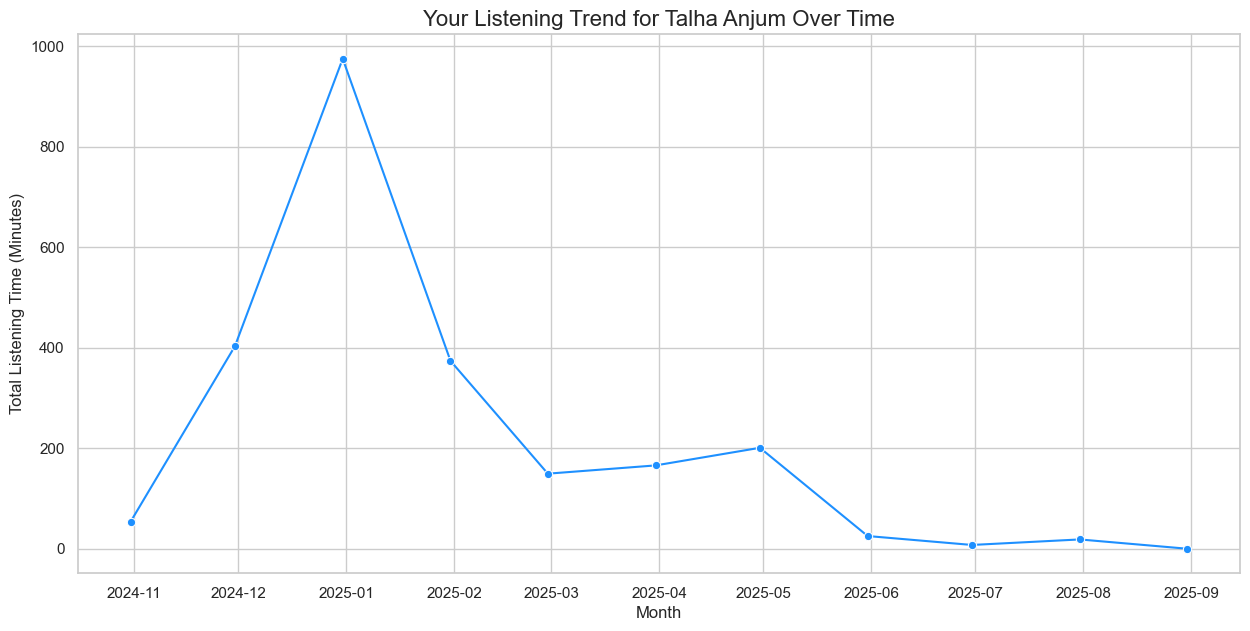

In [29]:
if not df.empty:
    artist_name = 'Talha Anjum' # You can change this to any artist
    df_artist = df[df['master_metadata_album_artist_name'] == artist_name].copy()

    if df_artist.empty:
        print(f"It looks like there's no listening data for '{artist_name}' in your history.")
    else:
        df_artist.set_index('ts', inplace=True)
        # Resample by month and sum the listening time in minutes
        monthly_listening_minutes = df_artist['ms_played'].resample('ME').sum() / 60000

        # Create the line graph
        plt.figure(figsize=(15, 7))
        sns.lineplot(data=monthly_listening_minutes, marker='o', color='dodgerblue')
        plt.title(f'Your Listening Trend for {artist_name} Over Time', fontsize=16)
        plt.xlabel('Month')
        plt.ylabel('Total Listening Time (Minutes)')
        plt.grid(True)
        plt.show()

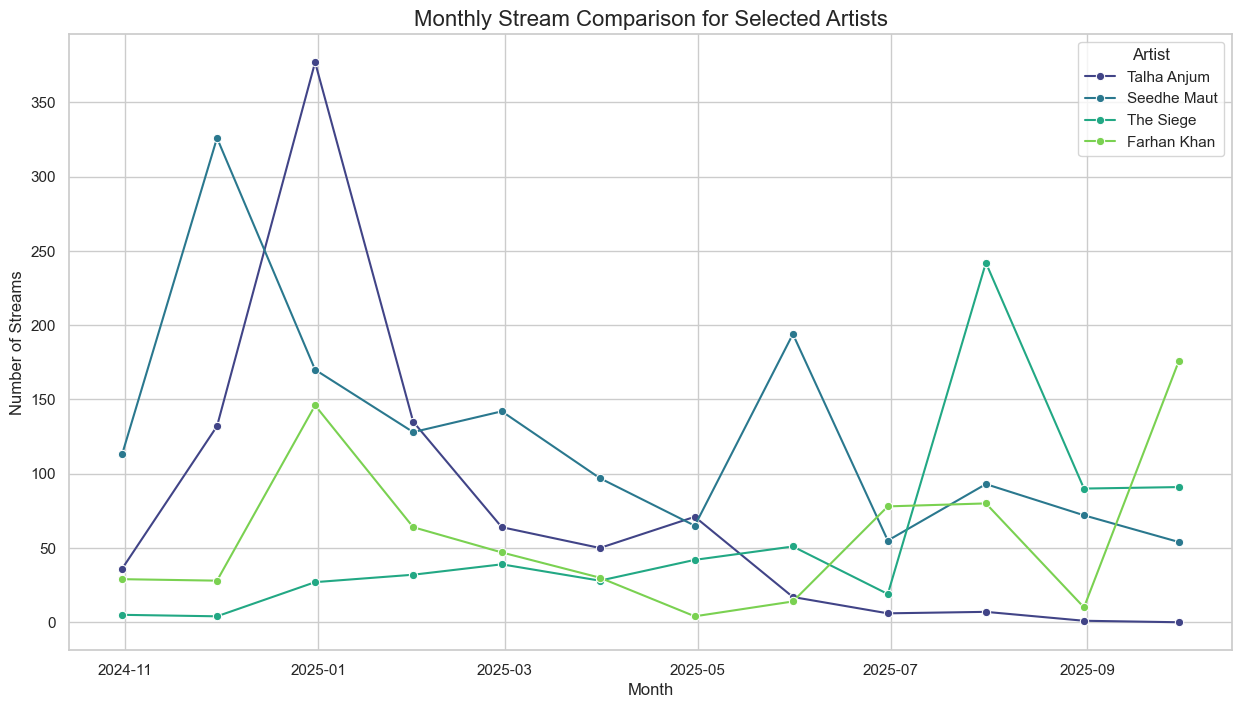

In [30]:
if not df.empty:
    artists_to_compare = ['Talha Anjum', 'Seedhe Maut', 'The Siege', 'Farhan Khan']
    artist_data = {}

    for artist in artists_to_compare:
        df_artist = df[df['master_metadata_album_artist_name'] == artist].copy()
        if not df_artist.empty:
            df_artist.set_index('ts', inplace=True)
            monthly_streams = df_artist.resample('ME').size()
            artist_data[artist] = monthly_streams

    if artist_data:
        comparison_df = pd.DataFrame(artist_data)
        comparison_df.fillna(0, inplace=True)

        plt.figure(figsize=(15, 8))
        # FIXED: Added palette="viridis"
        sns.lineplot(data=comparison_df, dashes=False, marker='o', palette="viridis")
        plt.title('Monthly Stream Comparison for Selected Artists', fontsize=16)
        plt.xlabel('Month')
        plt.ylabel('Number of Streams')
        plt.legend(title='Artist')
        plt.grid(True)
        plt.show()
    else:
        print("Could not find streaming data for any of the specified artists.")

Your Top 5 Artists (All Time): ['Seedhe Maut', 'Talha Anjum', 'Farhan Khan', 'The Siege', 'trick/switch']


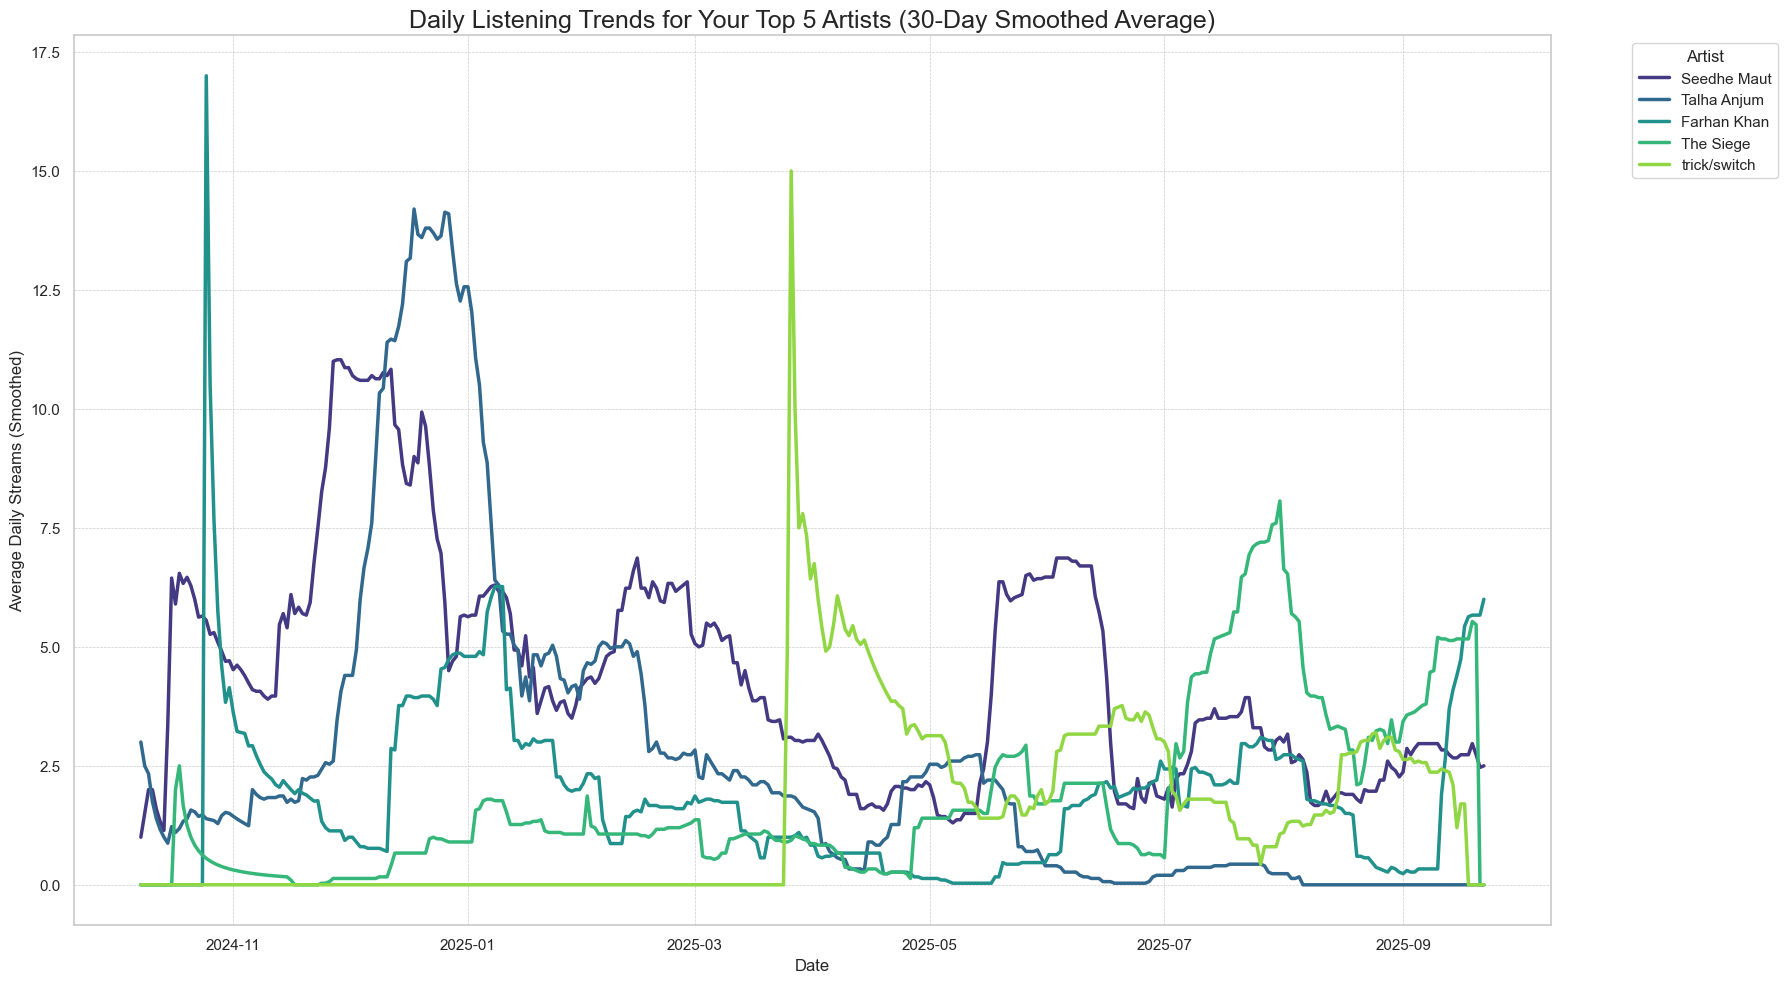

In [31]:
if not df.empty:
    try:
        top_5_artists = df['master_metadata_album_artist_name'].value_counts().head(5).index.tolist()
        print("Your Top 5 Artists (All Time):", top_5_artists)
        artist_daily_data = {}

        for artist in top_5_artists:
            df_artist = df[df['master_metadata_album_artist_name'] == artist].copy()
            df_artist.set_index('ts', inplace=True)
            daily_streams = df_artist.resample('D').size()

            # Calculate the 30-day rolling average
            smoothed_streams = daily_streams.rolling(window=30, min_periods=1).mean()
            artist_daily_data[artist] = smoothed_streams

        comparison_df_daily = pd.DataFrame(artist_daily_data)
        comparison_df_daily.fillna(0, inplace=True)

        plt.figure(figsize=(18, 10))
        # FIXED: Added palette="viridis"
        sns.lineplot(data=comparison_df_daily, dashes=False, lw=2.5, palette="viridis")
        plt.title('Daily Listening Trends for Your Top 5 Artists (30-Day Smoothed Average)', fontsize=18)
        plt.xlabel('Date')
        plt.ylabel('Average Daily Streams (Smoothed)')
        plt.legend(title='Artist', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, which='both', linestyle='--', linewidth=0.5)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"An error occurred while generating the daily trends chart: {e}")